In [1]:
import colorcet
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import scipy.stats

from lib.plots import set_axis, attach_colorbar, kde1d_at
from lib.stats import fit_power_law

In [2]:
metrics_table = pl.read_csv("metrics.csv")

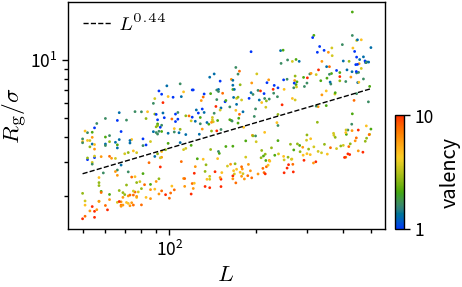

In [14]:
fig, ax = plt.subplots()

sm = plt.cm.ScalarMappable(
    norm=plt.cm.colors.Normalize(),
    cmap=colorcet.m_rainbow,
)

x = metrics_table["chain_length"]
y = metrics_table["rg_mean"]
z = metrics_table["association_valency"]
ax.scatter(x, y, c=z, norm=sm.norm, cmap=sm.cmap, s=1)

alpha, beta = fit_power_law(x, y)
x = np.linspace(50, 500)
y = beta * x**alpha
s = r"$ L^{%.2f} $" % alpha
ax.plot(x, y, color="k", ls="--", label=s)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"$ L $", usetex=True)
ax.set_ylabel(r"$ R_\mathrm{g} / \sigma $", usetex=True)
legend = ax.legend(loc="upper left")
for text in legend.get_texts():
    text.set_usetex(True)

cbar = attach_colorbar(ax, sm)
cbar.set_label("valency")
cbar.set_ticks([1, 10])

pass

In [4]:
section = metrics_table.filter(
    (pl.col("association_valency") >= 8)
    & (pl.col("association_energy") >= 2)
)
x = section["chain_length"]
y = section["rg_mean"]
fit_power_law(x, y)

(0.33303927058747806, 0.4608895136583272)

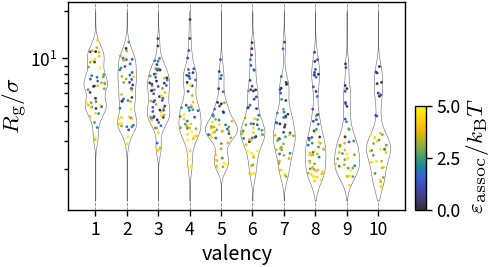

In [5]:
fig, ax = plt.subplots(figsize=(2.1, 1.4))

valency_values = np.arange(1, 11)
sm = plt.cm.ScalarMappable(
    norm=plt.cm.colors.Normalize(0, 5),
    cmap=colorcet.m_gouldian,
)
random = np.random.Generator(np.random.PCG64(1))

for v in valency_values:
    section = metrics_table.filter(pl.col("association_valency") == v)
    x = np.full(len(section), v, dtype=np.float32)
    y = section["rg_mean"]
    z = section["association_energy"]

    kde = scipy.stats.gaussian_kde(np.log10(y), bw_method=0.3)
    kde_scale = 0.16

    widths = 0.9 * kde_scale * kde(np.log10(y))
    x += random.uniform(-widths, widths, size=x.shape)

    env_dx = kde_scale * kde(np.log10(y))
    x_env_min = v - env_dx
    x_env_max = v + env_dx
    x = np.clip(x, x_env_min, x_env_max)

    ax.scatter(x, y, c=z, s=1, norm=sm.norm, cmap=sm.cmap, zorder=3)

    y = 10 ** np.linspace(0.1, 1.3)
    dx = kde_scale * kde(np.log10(y))
    x_min = v - dx
    x_max = v + dx
    ax.fill_betweenx(y, x_min, x_max, lw=0.2, ec="#666", fc="w", zorder=2)

ax.grid(True, axis="x", zorder=1)
ax.set_yscale("log")
ax.set_xticks(valency_values)

cbar = attach_colorbar(ax, sm)
cbar.set_label(r"$ \varepsilon_\mathrm{assoc} / k_\mathrm{B} T $", usetex=True)

ax.set_xlabel("valency")
ax.set_ylabel(r"$ R_\mathrm{g} / \sigma $", usetex=True)

pass

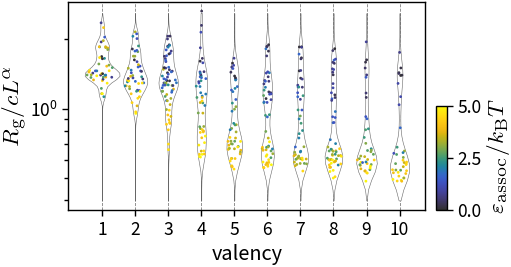

In [6]:
fig, ax = plt.subplots(figsize=(2.2, 1.4))

valency_values = np.arange(1, 11)
sm = plt.cm.ScalarMappable(
    norm=plt.cm.colors.Normalize(0, 5),
    cmap=colorcet.m_gouldian,
)
random = np.random.Generator(np.random.PCG64(1))

for v in valency_values:
    section = metrics_table.filter(pl.col("association_valency") == v)
    x = np.full(len(section), v, dtype=np.float32)
    y = section["rg_mean"] / (section["chain_length"]**alpha * beta)
    z = section["association_energy"]

    kde = scipy.stats.gaussian_kde(np.log10(y), bw_method=0.3)
    kde_scale = 0.07

    widths = 0.9 * kde_scale * kde(np.log10(y))
    x += random.uniform(-widths, widths, size=x.shape)

    env_dx = kde_scale * kde(np.log10(y))
    x_env_min = v - env_dx
    x_env_max = v + env_dx
    x = np.clip(x, x_env_min, x_env_max)

    ax.scatter(x, y, c=z, s=1, norm=sm.norm, cmap=sm.cmap, zorder=3)

    y = np.linspace(0.4, 2.6)
    dx = kde_scale * kde(np.log10(y))
    x_min = v - dx
    x_max = v + dx
    ax.fill_betweenx(y, x_min, x_max, lw=0.2, ec="#666", fc="w", zorder=2)

ax.grid(True, axis="x", zorder=1)
ax.set_yscale("log")
ax.set_xticks(valency_values)
ax.set_yticklabels([], minor=True)

cbar = attach_colorbar(ax, sm)
cbar.set_label(r"$ \varepsilon_\mathrm{assoc} / k_\mathrm{B} T $", usetex=True)

ax.set_xlabel("valency")
ax.set_ylabel(r"$ R_\mathrm{g} / c L^\alpha $", usetex=True)

pass

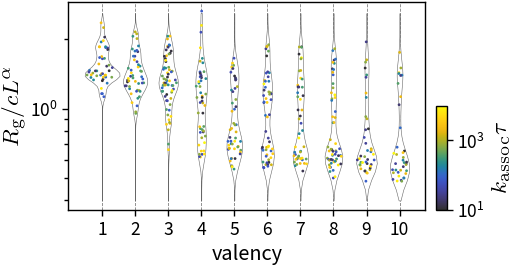

In [7]:
fig, ax = plt.subplots(figsize=(2.2, 1.4))

valency_values = np.arange(1, 11)
sm = plt.cm.ScalarMappable(
    norm=plt.cm.colors.LogNorm(1e1, 1e4),
    cmap=colorcet.m_gouldian,
)
random = np.random.Generator(np.random.PCG64(1))

for v in valency_values:
    section = metrics_table.filter(pl.col("association_valency") == v)
    x = np.full(len(section), v, dtype=np.float32)
    y = section["rg_mean"] / (section["chain_length"]**alpha * beta)
    z = section["association_rate"]

    kde = scipy.stats.gaussian_kde(np.log10(y), bw_method=0.3)
    kde_scale = 0.07

    widths = 0.9 * kde_scale * kde(np.log10(y))
    x += random.uniform(-widths, widths, size=x.shape)

    env_dx = kde_scale * kde(np.log10(y))
    x_env_min = v - env_dx
    x_env_max = v + env_dx
    x = np.clip(x, x_env_min, x_env_max)

    ax.scatter(x, y, c=z, s=1, norm=sm.norm, cmap=sm.cmap, zorder=3)

    y = np.linspace(0.4, 2.6)
    dx = kde_scale * kde(np.log10(y))
    x_min = v - dx
    x_max = v + dx
    ax.fill_betweenx(y, x_min, x_max, lw=0.2, ec="#666", fc="w", zorder=2)

ax.grid(True, axis="x", zorder=1)
ax.set_yscale("log")
ax.set_xticks(valency_values)
ax.set_yticklabels([], minor=True)

ax.set_xlabel("valency")
ax.set_ylabel(r"$ R_\mathrm{g} / c L^\alpha $", usetex=True)

cbar = attach_colorbar(ax, sm)
#cbar.set_label(r"$ \varepsilon_\mathrm{assoc} / k_\mathrm{B} T $", usetex=True)
cbar.set_label(r"$ k_\mathrm{assoc} \tau $", usetex=True)

pass

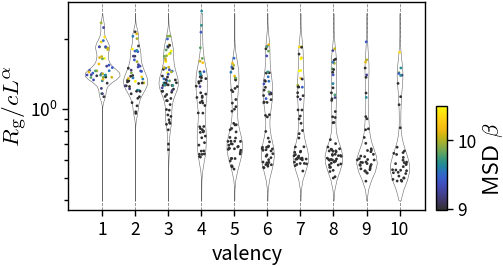

In [19]:
fig, ax = plt.subplots(figsize=(2.2, 1.4))

valency_values = np.arange(1, 11)
sm = plt.cm.ScalarMappable(
    norm=plt.cm.colors.Normalize(),
    cmap=colorcet.m_gouldian,
)
random = np.random.Generator(np.random.PCG64(1))

for v in valency_values:
    section = metrics_table.filter(pl.col("association_valency") == v)
    x = np.full(len(section), v, dtype=np.float32)
    y = section["rg_mean"] / (section["chain_length"]**alpha * beta)
    z = section["msd_beta"]

    kde = scipy.stats.gaussian_kde(np.log10(y), bw_method=0.3)
    kde_scale = 0.07

    widths = 0.9 * kde_scale * kde(np.log10(y))
    x += random.uniform(-widths, widths, size=x.shape)

    env_dx = kde_scale * kde(np.log10(y))
    x_env_min = v - env_dx
    x_env_max = v + env_dx
    x = np.clip(x, x_env_min, x_env_max)

    ax.scatter(x, y, c=z, s=1, norm=sm.norm, cmap=sm.cmap, zorder=3)

    y = np.linspace(0.4, 2.6)
    dx = kde_scale * kde(np.log10(y))
    x_min = v - dx
    x_max = v + dx
    ax.fill_betweenx(y, x_min, x_max, lw=0.2, ec="#666", fc="w", zorder=2)

ax.grid(True, axis="x", zorder=1)
ax.set_yscale("log")
ax.set_xticks(valency_values)
ax.set_yticklabels([], minor=True)

ax.set_xlabel("valency")
ax.set_ylabel(r"$ R_\mathrm{g} / c L^\alpha $", usetex=True)

cbar = attach_colorbar(ax, sm)
cbar.set_label(r"MSD $ \beta $", usetex=True)

pass

In [8]:
(
    metrics_table
    # .filter(pl.col("association_valency") == 4)
    .with_columns(
        norm_rg=(pl.col("rg_mean") / (pl.col("chain_length")**alpha * beta)),
    )
    .sort(by="norm_rg")
    .filter(pl.col("config_id") == 101)
)

config_id,chain_length,association_valency,association_rate,association_constant,association_energy,extruder_loading_constant,rg_mean,rg_stddev,msd_alpha,msd_beta,norm_rg
i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
101,338,8,718.135761,1.036462,1.492801,0.034456,6.609198,6.609198,0.548718,8.370319,1.103334
